# 건설현장 산업재해 발생 영향 요인 분석

**RQ**: 건설현장의 내부 안전 관리와 실질적 안전 행동이 산업재해 발생에 미치는 영향 — 외부 기관의 조절효과를 중심으로

**분석 구조 (KEY PAPER 기반)**
- Phase 1: EDA & 기술통계
- Phase 2: Logistic Regression — 계층적 회귀 (statsmodels)
- Phase 3: ML 모델 비교 (imblearn Pipeline + SMOTENC + 5-Fold CV)
- Phase 4: SHAP 분석 (최적 모델)

## 0. 환경 설정

In [2]:
!pip install -q statsmodels koreanize-matplotlib imbalanced-learn xgboost lightgbm shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression as LR_sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

In [4]:
# 데이터 로드
df = pd.read_csv('/content/전처리_최종.csv')

# 변수 그룹 정의 (RQ 기반)
IND_A  = ['안전조직수준', '위원회수준', '인증보유']
IND_B  = ['위험성평가수준', '교육훈련도움', '정리정돈상태', '작업중지권', '작업반장기여']
MOD    = ['전문지도', '고용노동부감독', '안전보건공단지원']
CTRL   = ['공사규모', '발주처', '기성공정률', '공사종류', '외국인비율']
TARGET = '사고발생'

IND_ALL      = IND_A + IND_B
ALL_FEATURES = IND_ALL + MOD + CTRL

# SMOTENC용: 외국인비율(인덱스 15)만 연속형, 나머지 15개 범주형
CAT_IDX = [i for i, col in enumerate(ALL_FEATURES) if col != '외국인비율']

X = df[ALL_FEATURES]
y = df[TARGET]

print(f"데이터: {df.shape[0]}개 사업장, {df.shape[1]}개 변수")
print(f"범주형 인덱스 (SMOTENC): {CAT_IDX}")
print(f"연속형: 외국인비율 (인덱스 {ALL_FEATURES.index('외국인비율')})")

데이터: 1375개 사업장, 17개 변수
범주형 인덱스 (SMOTENC): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
연속형: 외국인비율 (인덱스 15)


---
## Phase 1. EDA & 기술통계

In [5]:
# 기초 통계량
display(df.describe().round(2))

,안전조직수준,위원회수준,인증보유,위험성평가수준,교육훈련도움,정리정돈상태,작업중지권,작업반장기여,전문지도,고용노동부감독,안전보건공단지원,공사규모,발주처,기성공정률,공사종류,외국인비율,사고발생
count,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00,1375.00
mean,1.67,1.61,0.32,1.78,4.31,4.22,4.35,4.13,0.36,0.51,0.78,1.94,1.75,3.15,3.29,13.30,0.28
std,0.51,0.70,0.47,0.59,0.74,0.76,0.75,0.82,0.48,0.50,0.41,0.73,0.64,1.60,1.94,19.02,0.45
min,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00
25%,1.00,1.00,0.00,2.00,4.00,4.00,4.00,4.00,0.00,0.00,1.00,1.00,1.00,2.00,1.00,0.00,0.00
50%,2.00,2.00,0.00,2.00,4.00,4.00,4.00,4.00,0.00,1.00,1.00,2.00,2.00,3.00,3.00,0.00,0.00
75%,2.00,2.00,1.00,2.00,5.00,5.00,5.00,5.00,1.00,1.00,1.00,2.00,2.00,4.00,5.00,22.04,1.00
max,2.00,2.00,1.00,2.00,5.00,5.00,5.00,5.00,1.00,1.00,1.00,3.00,3.00,6.00,7.00,100.00,1.00


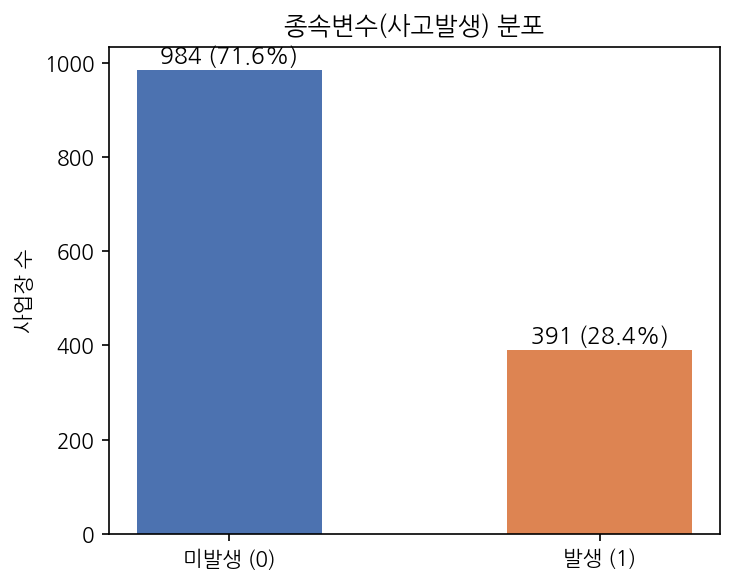

In [6]:
# 종속변수 분포
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts().sort_index()
bars = ax.bar([0, 1], counts.values, color=['#4C72B0', '#DD8452'], width=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{count} ({pct:.1f}%)', ha='center', fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(['미발생 (0)', '발생 (1)'])
ax.set_ylabel('사업장 수')
ax.set_title('종속변수(사고발생) 분포')
plt.tight_layout()
plt.show()

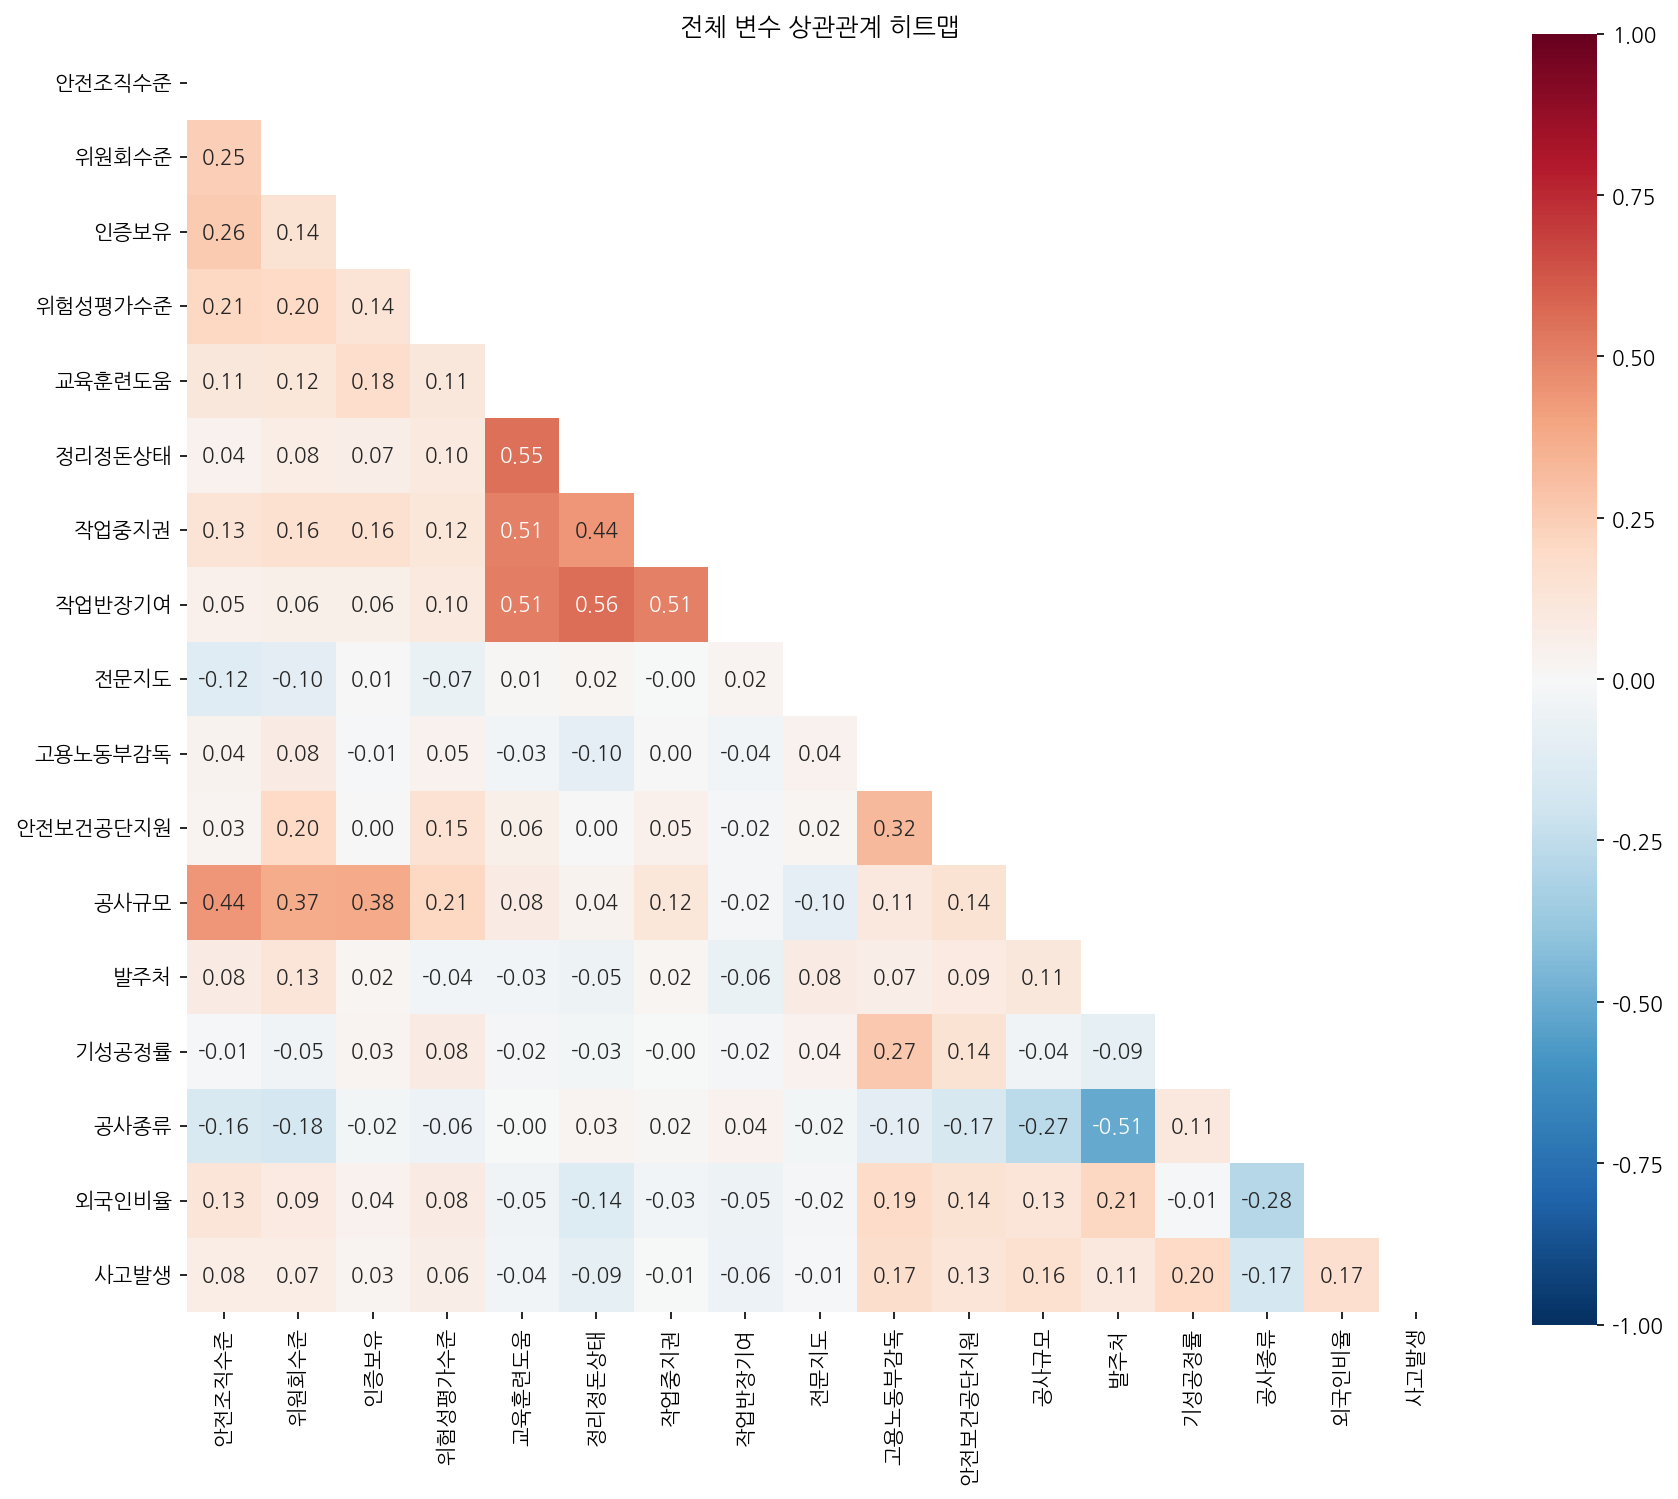

In [7]:
# 상관관계 히트맵
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, ax=ax)
ax.set_title('전체 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

In [8]:
# VIF 다중공선성 검증
X_vif = sm.add_constant(df[ALL_FEATURES])
vif = pd.DataFrame({
    '변수명': ALL_FEATURES,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(ALL_FEATURES))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("다중공선성(VIF) 검증 결과:")
display(vif)

다중공선성(VIF) 검증 결과:


,변수명,VIF
0,교육훈련도움,1.761446
1,정리정돈상태,1.760167
2,작업반장기여,1.752095
3,공사규모,1.614864
4,작업중지권,1.594050
5,공사종류,1.539643
6,발주처,1.402493
7,안전조직수준,1.316753
8,위원회수준,1.253844
9,인증보유,1.247447


---
## Phase 2. Logistic Regression — 계층적 회귀

변수를 단계적으로 투입하여 각 그룹의 설명력 기여를 확인한다.

| 모형 | 투입 변수 | 목적 |
|:---|:---|:---|
| Model 1 | 통제변수 | 기저 설명력 |
| Model 2 | + 독립A (내부 관리) | 내부 관리의 추가 설명력 |
| Model 3 | + 독립B (안전 행동) | 안전 행동의 추가 설명력 |
| Model 4 | + 조절변수 | 주효과 모형 |
| Model 5 | + 상호작용항 | 조절효과 검증 |

In [9]:
def fit_logit(y, X_df, name):
    X_c = sm.add_constant(X_df)
    model = sm.Logit(y, X_c).fit(maxiter=1000, disp=0)

    res = model.summary2().tables[1].copy()
    res['OR'] = np.exp(res['Coef.'])
    res['OR_Lower'] = np.exp(res['[0.025'])
    res['OR_Upper'] = np.exp(res['0.975]'])
    res['Sig'] = res['P>|z|'].apply(
        lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else ''))
    )
    out = res[['Coef.', 'Std.Err.', 'z', 'P>|z|', 'Sig', 'OR', 'OR_Lower', 'OR_Upper']].round(4)

    print(f"\n[{name}]")
    print(f"  Pseudo R2={model.prsquared:.4f}  AIC={model.aic:.1f}  BIC={model.bic:.1f}  "
          f"Log-L={model.llf:.1f}  LLR p={model.llr_pvalue:.2e}")
    display(out)
    return model, out

In [10]:
m1, s1 = fit_logit(y, df[CTRL], "Model 1: 통제변수")


[Model 1: 통제변수]
  Pseudo R2=0.0927  AIC=1501.7  BIC=1533.0  Log-L=-744.8  LLR p=4.63e-31


,Coef.,Std.Err.,z,P>|z|,Sig,OR,OR_Lower,OR_Upper
const,-2.7567,0.3946,-6.9851,0.0000,***,0.0635,0.0293,0.1376
공사규모,0.3849,0.0902,4.2695,0.0000,***,1.4695,1.2315,1.7535
발주처,0.1236,0.1151,1.0745,0.2826,,1.1316,0.9031,1.4178
기성공정률,0.3322,0.0404,8.2146,0.0000,***,1.3940,1.2878,1.5090
공사종류,-0.1496,0.0406,-3.6859,0.0002,***,0.8611,0.7952,0.9324
외국인비율,0.0146,0.0033,4.4820,0.0000,***,1.0147,1.0083,1.0212


In [11]:
m2, s2 = fit_logit(y, df[CTRL + IND_A], "Model 2: 통제 + 독립A")


[Model 2: 통제 + 독립A]
  Pseudo R2=0.0939  AIC=1505.7  BIC=1552.7  Log-L=-743.8  LLR p=2.66e-29


,Coef.,Std.Err.,z,P>|z|,Sig,OR,OR_Lower,OR_Upper
const,-2.8150,0.4414,-6.3767,0.0000,***,0.0599,0.0252,0.1423
공사규모,0.4394,0.1089,4.0364,0.0001,***,1.5518,1.2536,1.9209
발주처,0.1243,0.1151,1.0795,0.2804,,1.1324,0.9036,1.4190
기성공정률,0.3357,0.0406,8.2686,0.0000,***,1.3989,1.2919,1.5148
공사종류,-0.1463,0.0408,-3.5889,0.0003,***,0.8639,0.7976,0.9358
외국인비율,0.0147,0.0033,4.4869,0.0000,***,1.0148,1.0083,1.0213
안전조직수준,-0.0331,0.1458,-0.2272,0.8203,,0.9674,0.7270,1.2874
위원회수준,0.0280,0.1040,0.2691,0.7879,,1.0284,0.8388,1.2608
인증보유,-0.1987,0.1488,-1.3358,0.1816,,0.8198,0.6124,1.0973


In [12]:
m3, s3 = fit_logit(y, df[CTRL + IND_A + IND_B], "Model 3: 통제 + 독립A + 독립B")


[Model 3: 통제 + 독립A + 독립B]
  Pseudo R2=0.0992  AIC=1506.9  BIC=1580.1  Log-L=-739.4  LLR p=5.03e-28


,Coef.,Std.Err.,z,P>|z|,Sig,OR,OR_Lower,OR_Upper
const,-2.0607,0.6203,-3.3218,0.0009,***,0.1274,0.0378,0.4296
공사규모,0.4337,0.1099,3.9453,0.0001,***,1.5429,1.2439,1.9138
발주처,0.1047,0.1165,0.8986,0.3689,,1.1103,0.8837,1.3951
기성공정률,0.3340,0.0409,8.1610,0.0000,***,1.3966,1.2889,1.5132
공사종류,-0.1513,0.0411,-3.6808,0.0002,***,0.8596,0.7930,0.9317
외국인비율,0.0134,0.0033,4.0222,0.0001,***,1.0134,1.0069,1.0201
안전조직수준,-0.0380,0.1477,-0.2575,0.7968,,0.9627,0.7207,1.2859
위원회수준,0.0342,0.1065,0.3205,0.7486,,1.0347,0.8397,1.2750
인증보유,-0.1909,0.1517,-1.2582,0.2083,,0.8262,0.6136,1.1124
위험성평가수준,0.0766,0.1252,0.6118,0.5407,,1.0796,0.8447,1.3798


In [13]:
m4, s4 = fit_logit(y, df[ALL_FEATURES], "Model 4: 주효과 모형 (전체)")


[Model 4: 주효과 모형 (전체)]
  Pseudo R2=0.1044  AIC=1504.5  BIC=1593.3  Log-L=-735.2  LLR p=4.56e-28


,Coef.,Std.Err.,z,P>|z|,Sig,OR,OR_Lower,OR_Upper
const,-2.2001,0.6296,-3.4946,0.0005,***,0.1108,0.0323,0.3805
안전조직수준,-0.0241,0.1487,-0.1620,0.8713,,0.9762,0.7294,1.3065
위원회수준,0.0009,0.1082,0.0081,0.9935,,1.0009,0.8096,1.2374
인증보유,-0.1529,0.1529,-0.9994,0.3176,,0.8582,0.6360,1.1583
위험성평가수준,0.0626,0.1265,0.4947,0.6208,,1.0646,0.8308,1.3643
교육훈련도움,-0.0064,0.1132,-0.0566,0.9548,,0.9936,0.7960,1.2403
정리정돈상태,-0.2338,0.1082,-2.1612,0.0307,*,0.7915,0.6403,0.9785
작업중지권,0.0661,0.1049,0.6298,0.5288,,1.0683,0.8697,1.3122
작업반장기여,-0.0193,0.1002,-0.1930,0.8470,,0.9809,0.8060,1.1936
전문지도,-0.0851,0.1366,-0.6230,0.5333,,0.9184,0.7028,1.2003


In [14]:
# Model 5: 조절효과 모형 (독립 x 조절 상호작용항)
X_inter = df[ALL_FEATURES].copy()
inter_terms = []
for ind in IND_ALL:
    for mod in MOD:
        name = f'{ind}x{mod}'
        X_inter[name] = X_inter[ind] * X_inter[mod]
        inter_terms.append(name)

m5, s5 = fit_logit(y, X_inter, "Model 5: 조절효과 모형")


[Model 5: 조절효과 모형]
  Pseudo R2=0.1212  AIC=1524.8  BIC=1739.1  Log-L=-721.4  LLR p=5.70e-23


,Coef.,Std.Err.,z,P>|z|,Sig,OR,OR_Lower,OR_Upper
const,-1.8013,1.4545,-1.2385,0.2155,,0.1651,0.0095,2.8559
안전조직수준,-0.0567,0.3852,-0.1473,0.8829,,0.9448,0.4441,2.0101
위원회수준,0.1292,0.2454,0.5267,0.5984,,1.1380,0.7035,1.8408
인증보유,-0.3420,0.4052,-0.8441,0.3986,,0.7103,0.3210,1.5718
위험성평가수준,0.1668,0.2923,0.5706,0.5682,,1.1815,0.6663,2.0952
교육훈련도움,-0.1371,0.2934,-0.4673,0.6403,,0.8719,0.4905,1.5496
정리정돈상태,-0.6779,0.2880,-2.3542,0.0186,*,0.5077,0.2887,0.8927
작업중지권,0.2077,0.2906,0.7148,0.4748,,1.2309,0.6964,2.1756
작업반장기여,0.2071,0.3117,0.6646,0.5063,,1.2302,0.6678,2.2660
전문지도,-0.1168,1.0738,-0.1088,0.9134,,0.8897,0.1085,7.2987


In [15]:
# 계층적 회귀 비교표
hier = pd.DataFrame({
    'Model': ['M1: 통제', 'M2: +독립A', 'M3: +독립A+B', 'M4: +조절', 'M5: +상호작용'],
    'Pseudo_R2': [m.prsquared for m in [m1, m2, m3, m4, m5]],
    'AIC': [m.aic for m in [m1, m2, m3, m4, m5]],
    'BIC': [m.bic for m in [m1, m2, m3, m4, m5]],
    'Log_L': [m.llf for m in [m1, m2, m3, m4, m5]],
    'n_vars': [m.df_model for m in [m1, m2, m3, m4, m5]],
}).round(4)

print("\n[계층적 회귀 모형 비교]")
display(hier)


[계층적 회귀 모형 비교]


,Model,Pseudo_R2,AIC,BIC,Log_L,n_vars
0,M1: 통제,0.0927,1501.6669,1533.0242,-744.8335,5.0
1,M2: +독립A,0.0939,1505.6681,1552.7040,-743.8341,8.0
2,M3: +독립A+B,0.0992,1506.8958,1580.0627,-739.4479,13.0
3,M4: +조절,0.1044,1504.4911,1593.3366,-735.2455,16.0
4,M5: +상호작용,0.1212,1524.8454,1739.1200,-721.4227,40.0


In [16]:
# 변수 그룹별 설명력 기여도 (Delta R2 + 우도비 검정)
from scipy.stats import chi2

def lr_test(model_restricted, model_full, label):
    lr_stat = -2 * (model_restricted.llf - model_full.llf)
    df_diff = model_full.df_model - model_restricted.df_model
    p_val = chi2.sf(lr_stat, df_diff)
    delta_r2 = model_full.prsquared - model_restricted.prsquared
    return {
        'Comparison': label,
        'Delta_R2': round(delta_r2, 4),
        'LR_Stat': round(lr_stat, 2),
        'df': int(df_diff),
        'p_value': f'{p_val:.4e}',
        'Sig': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    }

delta_tests = pd.DataFrame([
    lr_test(m1, m2, 'M1->M2: 독립A(내부관리) 추가'),
    lr_test(m2, m3, 'M2->M3: 독립B(안전행동) 추가'),
    lr_test(m3, m4, 'M3->M4: 조절변수 추가'),
    lr_test(m4, m5, 'M4->M5: 상호작용항 추가'),
])

print("[변수 그룹별 설명력 기여도 - 우도비 검정(LR Test)]")
display(delta_tests)

[변수 그룹별 설명력 기여도 - 우도비 검정(LR Test)]


,Comparison,Delta_R2,LR_Stat,df,p_value,Sig
0,M1->M2: 독립A(내부관리) 추가,0.0012,2.00,3,5.7265e-01,
1,M2->M3: 독립B(안전행동) 추가,0.0053,8.77,5,1.1850e-01,
2,M3->M4: 조절변수 추가,0.0051,8.40,3,3.8347e-02,*
3,M4->M5: 상호작용항 추가,0.0168,27.65,24,2.7527e-01,


In [17]:
# 유의미한 상호작용항 (p < 0.1)
sig_inter = s5[s5.index.isin(inter_terms) & (s5['P>|z|'] < 0.1)]
print("[유의미한 상호작용항 (p < 0.1)]")
if len(sig_inter) > 0:
    display(sig_inter[['Coef.', 'P>|z|', 'Sig', 'OR']])
else:
    print("  없음")

[유의미한 상호작용항 (p < 0.1)]


,Coef.,P>|z|,Sig,OR
인증보유x고용노동부감독,0.7327,0.0216,*,2.0808


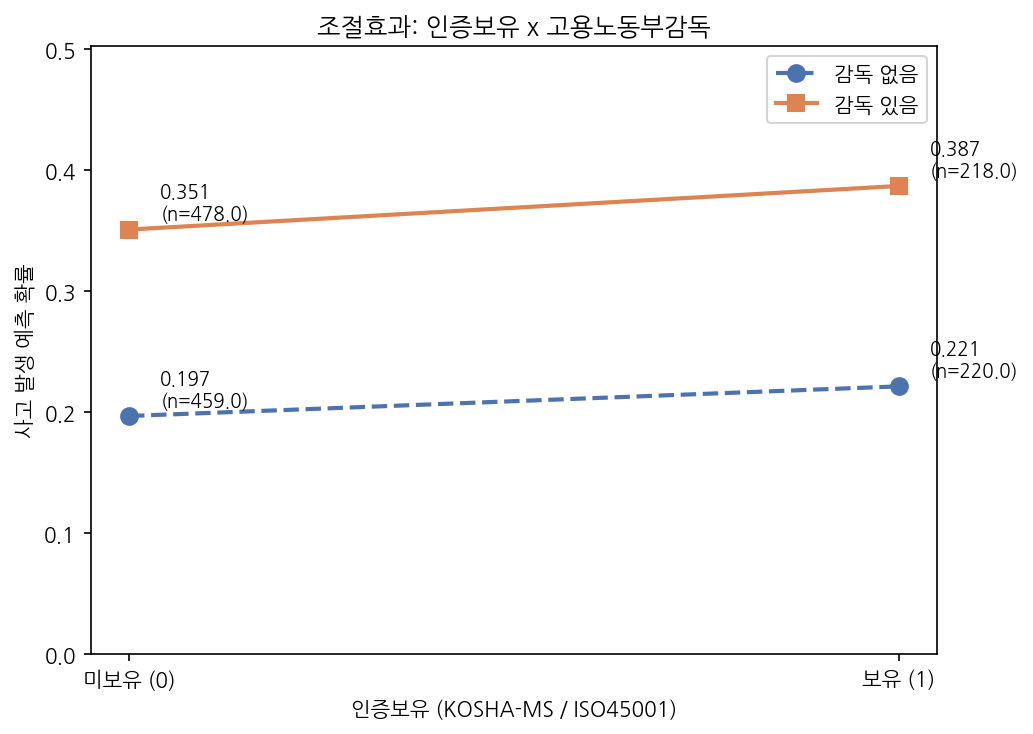

두 선의 기울기 차이가 조절효과의 크기를 나타낸다.
인증 보유 + 감독 수혜 사업장에서 사고확률이 급격히 높아지는 패턴은
고위험 대규모 현장일수록 인증과 감독을 동시에 받는 선택편향을 반영한다.


In [18]:
# 조절효과 시각화: Interaction Plot (인증보유 x 고용노동부감독)
# Model 4(주효과 모형) 기반 예측 확률로 시각화

X_plot = df[ALL_FEATURES].copy()
X_plot_const = sm.add_constant(X_plot)

# 4개 조합별 평균 예측확률 계산
groups = X_plot.groupby(['인증보유', '고용노동부감독'])
plot_data = []
for (cert, inspect), grp in groups:
    idx = grp.index
    pred_prob = m4.predict(X_plot_const.loc[idx])
    plot_data.append({
        '인증보유': int(cert),
        '고용노동부감독': int(inspect),
        '예측확률': pred_prob.mean(),
        'n': len(grp)
    })
plot_df = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(7, 5))
for inspect_val, style, color in [(0, '--o', '#4C72B0'), (1, '-s', '#DD8452')]:
    sub = plot_df[plot_df['고용노동부감독'] == inspect_val]
    label = f'감독 {"있음" if inspect_val else "없음"}'
    ax.plot(sub['인증보유'], sub['예측확률'], style, color=color,
            lw=2, markersize=8, label=label)
    for _, row in sub.iterrows():
        ax.annotate(f'{row["예측확률"]:.3f}\n(n={row["n"]})',
                    (row['인증보유'], row['예측확률']),
                    textcoords="offset points", xytext=(15, 5), fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(['미보유 (0)', '보유 (1)'])
ax.set_xlabel('인증보유 (KOSHA-MS / ISO45001)')
ax.set_ylabel('사고 발생 예측 확률')
ax.set_title('조절효과: 인증보유 x 고용노동부감독')
ax.legend()
ax.set_ylim(0, max(plot_df['예측확률']) * 1.3)
plt.tight_layout()
plt.show()

print("두 선의 기울기 차이가 조절효과의 크기를 나타낸다.")
print("인증 보유 + 감독 수혜 사업장에서 사고확률이 급격히 높아지는 패턴은")
print("고위험 대규모 현장일수록 인증과 감독을 동시에 받는 선택편향을 반영한다.")

---
## Phase 3. ML 모델 비교 (SMOTENC + 5-Fold CV)

**SMOTENC 사용 근거**: 16개 변수 중 15개가 정수형(이진/순서형/리커트/범주형), 연속형은 외국인비율 1개뿐. 일반 SMOTE는 이진변수에서 0.4 같은 비현실적 값을 생성하므로 SMOTENC를 사용한다.

**데이터 누수 방지**: `imblearn.pipeline.Pipeline`으로 각 CV fold 내부에서만 SMOTENC 적용.

**SMOTENC 적용 전 문제 (기존 코드 결과)**:
- Random Forest: Recall=0.136, F1=0.211
- LightGBM: Recall=0.000, F1=0.000
- 모델이 전부 '미발생'으로 예측하는 편향 발생

In [19]:
# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train 사고발생 비율: {y_train.mean():.3f}")
print(f"Test  사고발생 비율: {y_test.mean():.3f}")

Train: 1100, Test: 275
Train 사고발생 비율: 0.285
Test  사고발생 비율: 0.284


In [20]:
# 모델 정의
smotenc = SMOTENC(categorical_features=CAT_IDX, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_config = {
    'Logistic Regression': {
        'model': LR_sklearn(max_iter=1000, random_state=42),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__class_weight': ['balanced', None]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 10, None],
            'model__class_weight': ['balanced', None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.1],
            'model__scale_pos_weight': [1, 2.5]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.1],
            'model__class_weight': ['balanced', None]
        }
    }
}

In [21]:
# 학습 및 평가
results = []
best_models = {}

for name, cfg in models_config.items():
    print(f"--- {name} ---")

    pipe = ImbPipeline([('smote', smotenc), ('model', cfg['model'])])
    grid = GridSearchCV(pipe, cfg['params'], cv=skf, scoring='f1', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    yp = grid.best_estimator_.predict(X_test)
    yprob = grid.best_estimator_.predict_proba(X_test)[:, 1]

    r = {
        'Model': name,
        'Best_Params': str(grid.best_params_),
        'CV_F1': round(grid.best_score_, 4),
        'Accuracy': round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp, zero_division=0), 4),
        'Recall': round(recall_score(y_test, yp), 4),
        'F1': round(f1_score(y_test, yp), 4),
        'ROC_AUC': round(roc_auc_score(y_test, yprob), 4),
    }
    results.append(r)
    print(f"  CV F1={r['CV_F1']}  Test F1={r['F1']}  AUC={r['ROC_AUC']}")
    print(f"  Params: {grid.best_params_}\n")

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print("\n[ML 모델 비교 (Test Set)]")
display(results_df)

print()
print("[SMOTENC 적용 전/후 비교]")
print("  적용 전: Recall=0.13~0.14, F1=0.20~0.21, LightGBM Recall/F1=0.000")
print(f"  적용 후: Recall={results_df['Recall'].min():.2f}~{results_df['Recall'].max():.2f}, "
      f"F1={results_df['F1'].min():.2f}~{results_df['F1'].max():.2f}")
print("  -> 소수 클래스(사고발생=1) 탐지 능력 정상화")

--- Logistic Regression ---
  CV F1=0.5124  Test F1=0.4821  AUC=0.6933
  Params: {'model__C': 0.01, 'model__class_weight': 'balanced'}

--- Random Forest ---
  CV F1=0.5245  Test F1=0.5446  AUC=0.7164
  Params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__n_estimators': 200}

--- XGBoost ---
  CV F1=0.5382  Test F1=0.5268  AUC=0.7155
  Params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__scale_pos_weight': 1}

--- LightGBM ---
  CV F1=0.5382  Test F1=0.5278  AUC=0.7187
  Params: {'model__class_weight': 'balanced', 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}


[ML 모델 비교 (Test Set)]


,Model,Best_Params,CV_F1,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,"{'model__class_weight': 'balanced', 'model__ma...",0.5245,0.6655,0.4435,0.7051,0.5446,0.7164
1,LightGBM,"{'model__class_weight': 'balanced', 'model__le...",0.5382,0.6291,0.4130,0.7308,0.5278,0.7187
2,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.5382,0.6145,0.4041,0.7564,0.5268,0.7155
3,Logistic Regression,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.5124,0.6327,0.4017,0.6026,0.4821,0.6933



[SMOTENC 적용 전/후 비교]
  적용 전: Recall=0.13~0.14, F1=0.20~0.21, LightGBM Recall/F1=0.000
  적용 후: Recall=0.60~0.76, F1=0.48~0.54
  -> 소수 클래스(사고발생=1) 탐지 능력 정상화


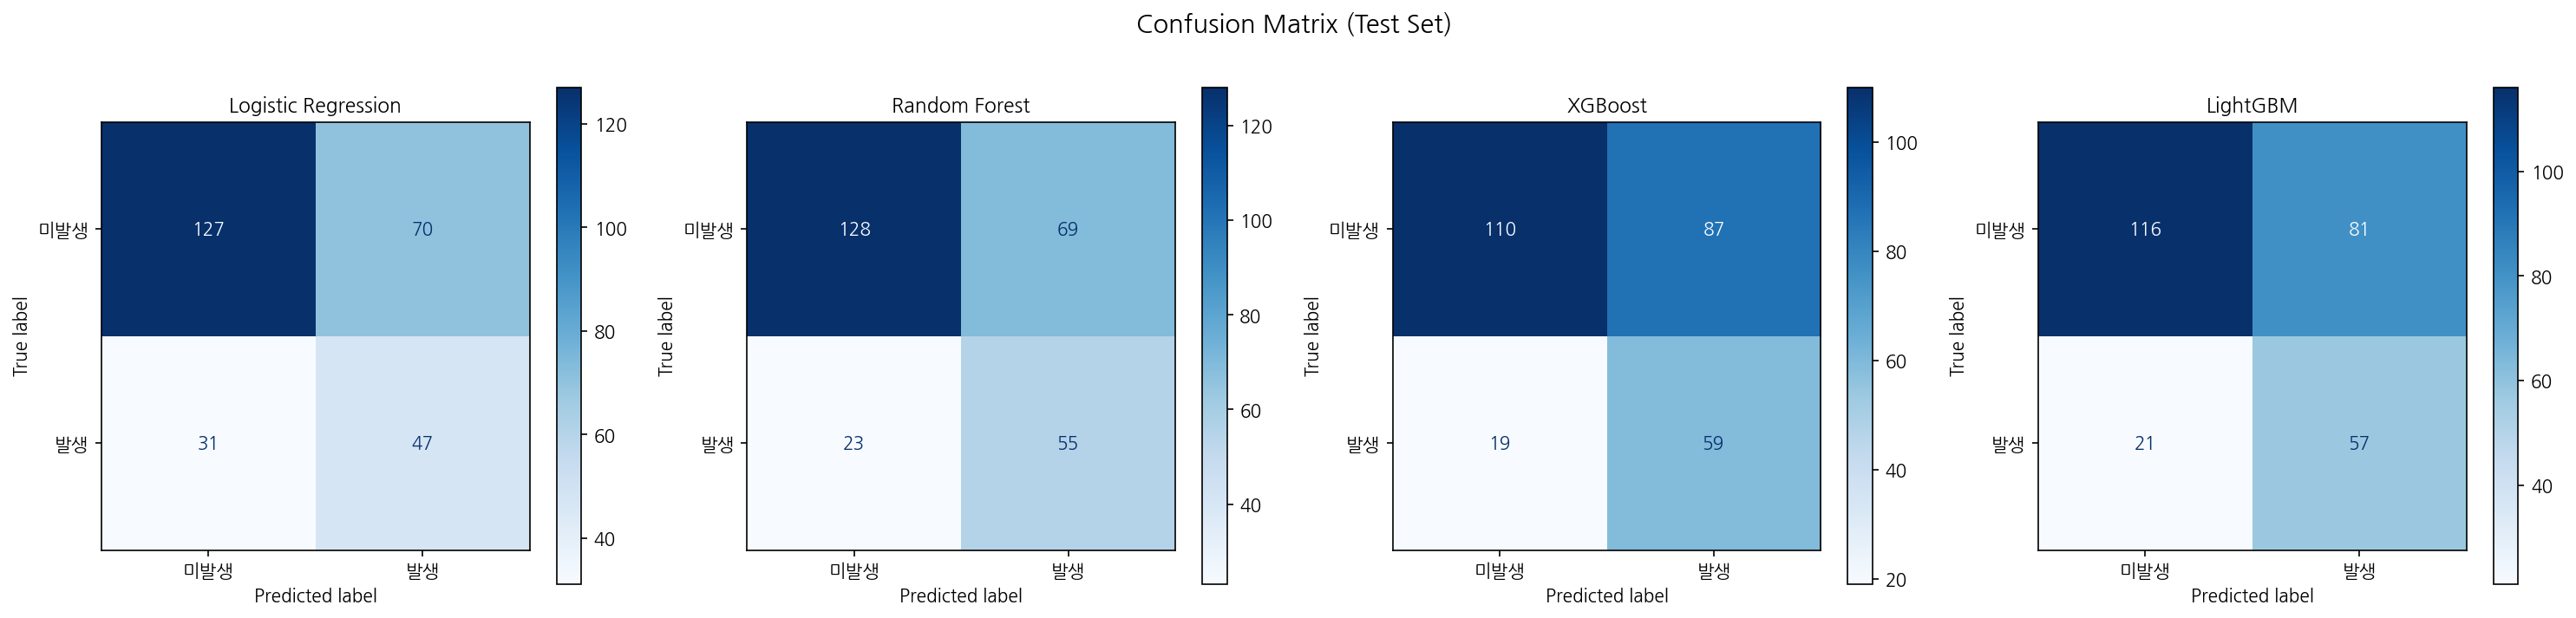

In [22]:
# Confusion Matrix
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, pipe) in zip(axes, best_models.items()):
    yp = pipe.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['미발생', '발생']).plot(ax=ax, cmap='Blues')
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrix (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

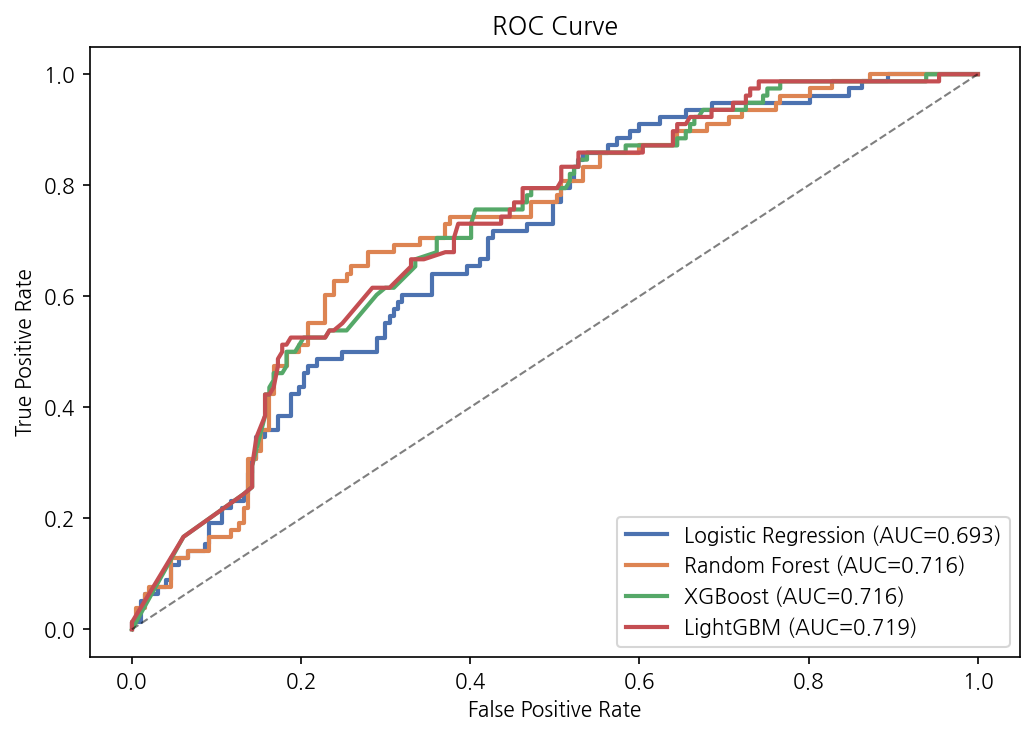

In [23]:
# ROC Curve 비교
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (name, pipe), c in zip(best_models.items(), colors):
    yprob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc_val = roc_auc_score(y_test, yprob)
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC={auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [24]:
# 최적 모델 Classification Report
best_name = results_df.iloc[0]['Model']
best_pipe = best_models[best_name]
yp_best = best_pipe.predict(X_test)

print(f"[최적 모델: {best_name}]")
print(classification_report(y_test, yp_best, target_names=['미발생', '발생']))

[최적 모델: Random Forest]
              precision    recall  f1-score   support

         미발생       0.85      0.65      0.74       197
          발생       0.44      0.71      0.54        78

    accuracy                           0.67       275
   macro avg       0.65      0.68      0.64       275
weighted avg       0.73      0.67      0.68       275



---
## Phase 4. SHAP 분석 (최적 모델)

In [25]:
# SHAP 값 산출
final_model = best_pipe.named_steps['model']

if isinstance(final_model, (RandomForestClassifier, XGBClassifier, LGBMClassifier)):
    explainer = shap.TreeExplainer(final_model)
else:
    explainer = shap.LinearExplainer(final_model, X_train)

shap_values = explainer.shap_values(X_test)

# 이진분류 클래스 1 기준
if isinstance(shap_values, list):
    shap_target = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_target = shap_values[:, :, 1]
else:
    shap_target = shap_values

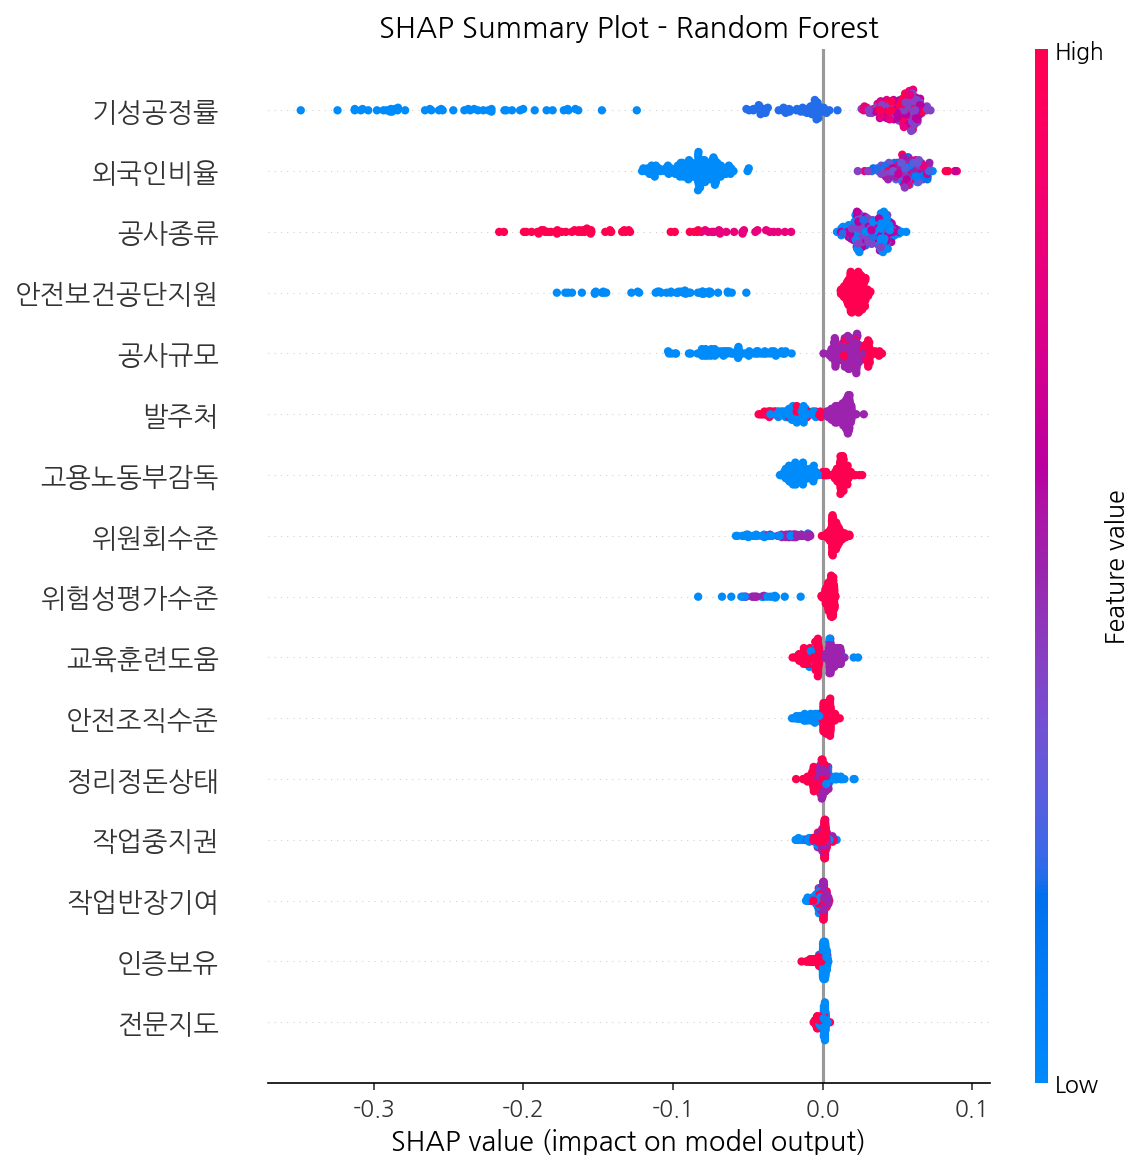

In [26]:
# SHAP Summary Plot (Dot)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_target, X_test, plot_type="dot", show=False, max_display=16)
plt.title(f"SHAP Summary Plot - {best_name}", fontsize=14)
plt.tight_layout()
plt.show()

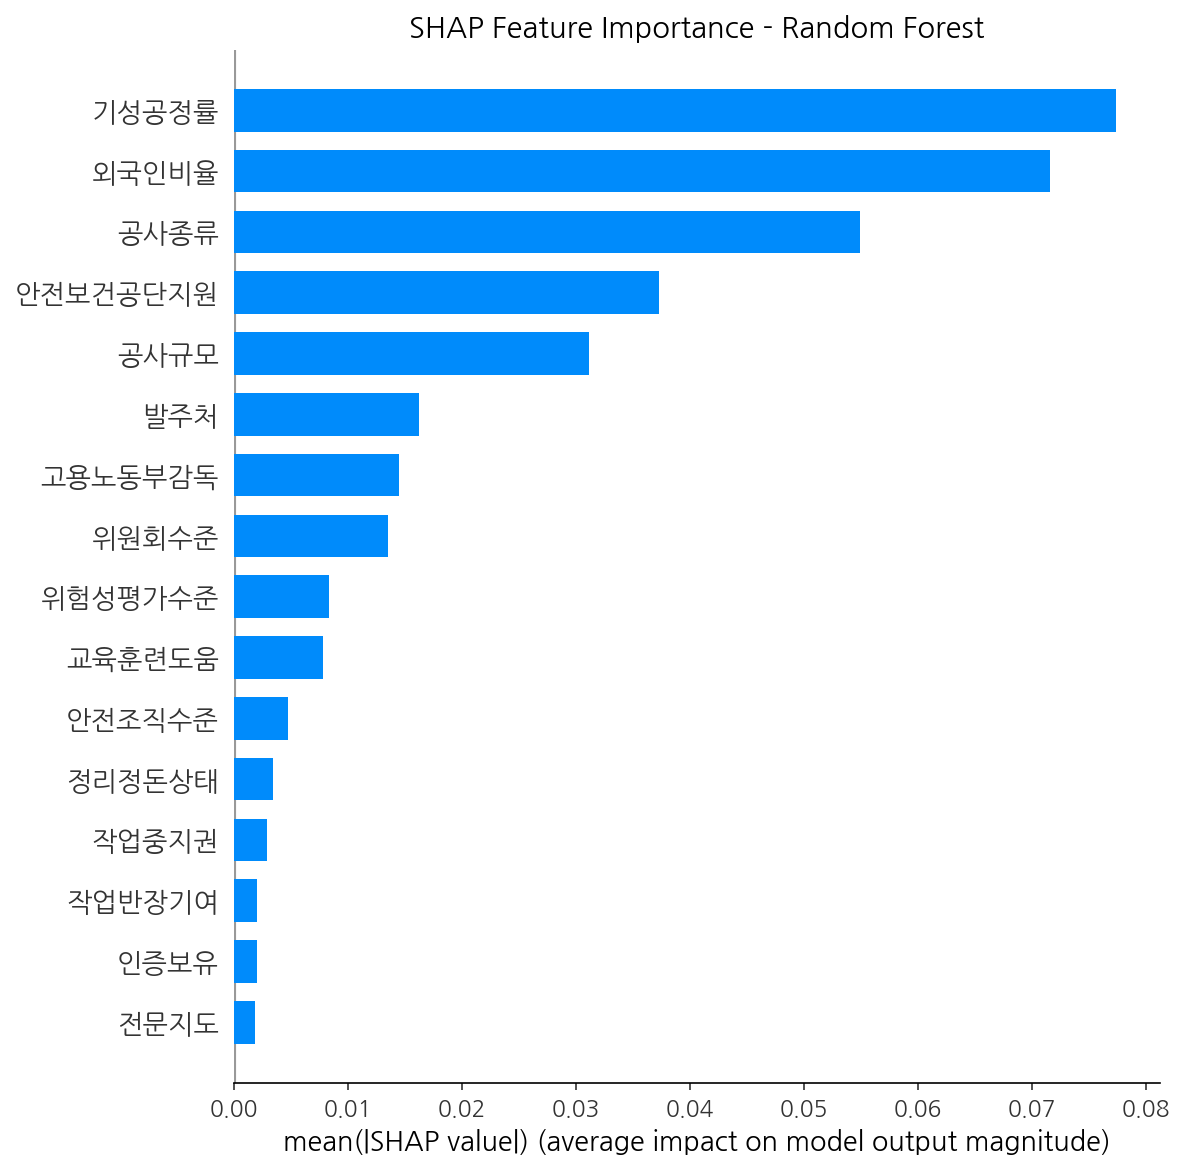

In [27]:
# SHAP Bar Plot (mean |SHAP|)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_target, X_test, plot_type="bar", show=False, max_display=16)
plt.title(f"SHAP Feature Importance - {best_name}", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# SHAP 방향성 검증: 정리정돈상태 (LR에서 유일하게 유의미한 독립변수)
# mean|SHAP| 순위는 낮지만, 방향성이 LR과 일치하는지 확인

feat_idx = ALL_FEATURES.index('정리정돈상태')
shap_vals = shap_target[:, feat_idx]
feat_vals = X_test['정리정돈상태'].values

print("[정리정돈상태 → LR vs SHAP 교차 검증]")
print(f"  LR: OR=0.792, p=0.031 → 정리정돈 높아질수록 사고 감소")
print(f"  SHAP mean|SHAP|: {np.abs(shap_vals).mean():.4f} (낮은 순위)")
print()

for v in sorted(X_test['정리정돈상태'].unique()):
    mask = feat_vals == v
    mean_shap = shap_vals[mask].mean()
    direction = '↓ 사고감소' if mean_shap < 0 else '↑ 사고증가'
    print(f"  정리정돈={int(v)}: 평균 SHAP={mean_shap:+.4f} {direction} (n={mask.sum()})")

print()
print("  ※ SHAP 크기는 작지만, 값이 높아질수록 SHAP이 음수로 가는 방향성이")
print("    LR의 OR<1 (보호 효과)과 일치함")
print("  ※ Tree 모델은 분산이 큰 변수(기성공정률 0~6, 외국인비율 0~100)의")
print("    split을 많이 하므로, 리커트 1~5 범위의 변수는 SHAP 크기가 작아지는")
print("    것은 모델 특성이지 변수의 중요성이 없다는 의미가 아님")


In [28]:
# SHAP Feature Importance 수치
shap_imp = pd.DataFrame({
    '변수명': ALL_FEATURES,
    'mean_abs_SHAP': np.abs(shap_target).mean(axis=0)
}).sort_values('mean_abs_SHAP', ascending=False).reset_index(drop=True)
shap_imp.index = range(1, len(shap_imp) + 1)
shap_imp.index.name = '순위'

print("[SHAP Feature Importance]")
display(shap_imp)

[SHAP Feature Importance]


,변수명,mean_abs_SHAP
순위,,
1,기성공정률,0.077386
2,외국인비율,0.071588
3,공사종류,0.054901
4,안전보건공단지원,0.037288
5,공사규모,0.031137
6,발주처,0.016280
7,고용노동부감독,0.014488
8,위원회수준,0.013587
9,위험성평가수준,0.008339


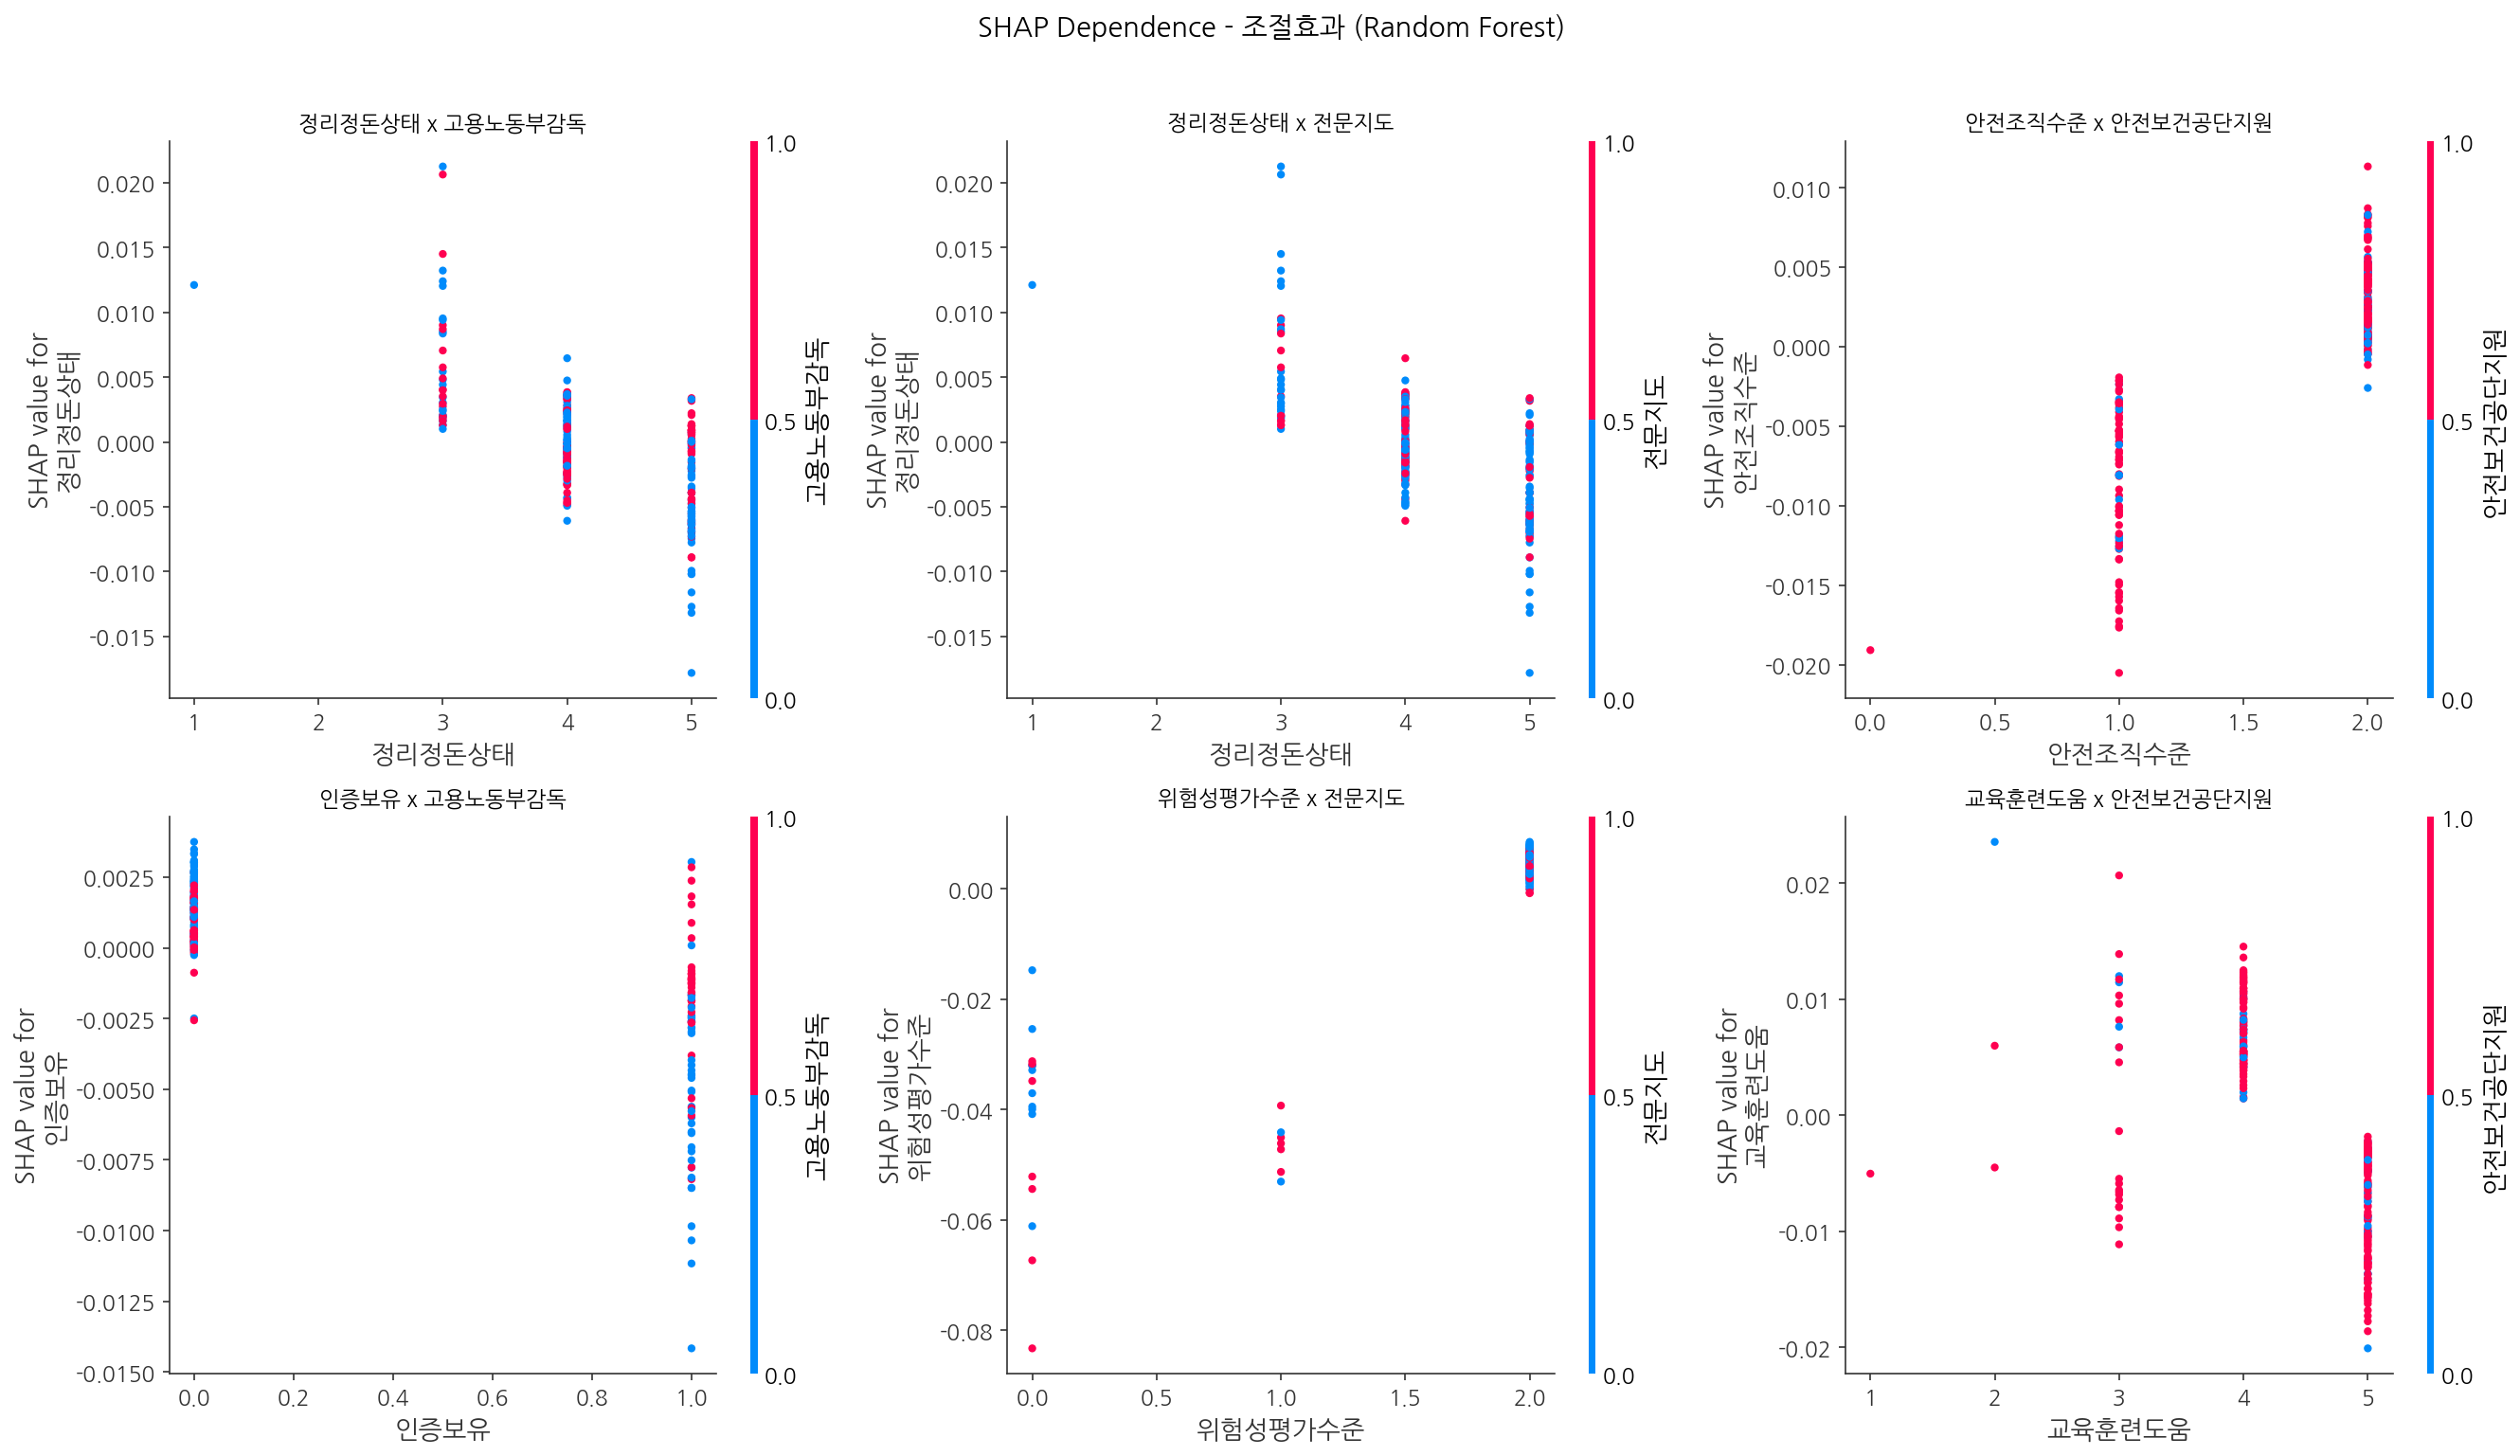

In [29]:
# SHAP Dependence Plots - 조절효과 시각화
pairs = [
    ('정리정돈상태', '고용노동부감독'),
    ('정리정돈상태', '전문지도'),
    ('안전조직수준', '안전보건공단지원'),
    ('인증보유', '고용노동부감독'),
    ('위험성평가수준', '전문지도'),
    ('교육훈련도움', '안전보건공단지원'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, (feat, interact) in enumerate(pairs):
    ax = axes[idx // 3, idx % 3]
    plt.sca(ax)
    shap.dependence_plot(feat, shap_target, X_test, interaction_index=interact, ax=ax, show=False)
    ax.set_title(f'{feat} x {interact}', fontsize=11)
plt.suptitle(f'SHAP Dependence - 조절효과 ({best_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 결과 요약

In [30]:
print("=" * 60)
print("1. 계층적 로지스틱 회귀")
print("=" * 60)
print(f"   Pseudo R2: M1={m1.prsquared:.4f} -> M4={m4.prsquared:.4f}")
print()

sig_m4 = s4[(s4['P>|z|'] < 0.05) & (s4.index != 'const')]
print("   Model 4 유의미한 변수 (p<0.05):")
for v in sig_m4.index:
    r = sig_m4.loc[v]
    d = '+' if r['OR'] > 1 else '-'
    print(f"     {v}: OR={r['OR']:.3f}({d}), p={r['P>|z|']:.4f} {r['Sig']}")

print()
print("   [핵심] 독립변수 8개 중 '정리정돈상태'만 유의미 (OR=0.792, p=0.031)")
print("   -> 형식적 관리체계(조직, 위원회, 인증)보다")
print("      현장의 실질적 안전 행동이 사고 감소에 기여")
print("   -> 정리정돈 수준 1단위 증가 시 사고 오즈 약 20.8% 감소")

print()
print("=" * 60)
print("2. ML 모델 비교 (SMOTENC)")
print("=" * 60)
for _, r in results_df.iterrows():
    print(f"   {r['Model']}: F1={r['F1']}, AUC={r['ROC_AUC']}")
print(f"   -> 최적 모델: {best_name}")
print()
print("   [SMOTENC 효과]")
print("   적용 전: Recall=0.13~0.14, F1=0.20, LightGBM=0.000")
print(f"   적용 후: Recall={results_df['Recall'].min():.2f}~{results_df['Recall'].max():.2f}, "
      f"F1={results_df['F1'].min():.2f}~{results_df['F1'].max():.2f}")

print()
print("=" * 60)
print("3. SHAP Top-5")
print("=" * 60)
for i, (_, r) in enumerate(shap_imp.head(5).iterrows(), 1):
    print(f"   {i}. {r['변수명']} ({r['mean_abs_SHAP']:.4f})")
print()
print("   [LR-SHAP 교차 검증]")
print("   - 통제변수: LR 유의미 → SHAP 상위권 (크기+방향 일치)")
print("   - 정리정돈상태: LR 유의미(OR=0.792) → SHAP 크기는 작지만")
print("     값이 높아질수록 SHAP 음수(보호 효과) 방향 일치")
print("   - 선형(LR) + 비선형(ML) 모두에서 동일 결론 → 결과 견고")

1. 계층적 로지스틱 회귀
   Pseudo R2: M1=0.0927 -> M4=0.1044

   Model 4 유의미한 변수 (p<0.05):
     정리정돈상태: OR=0.791(-), p=0.0307 *
     고용노동부감독: OR=1.334(+), p=0.0407 *
     공사규모: OR=1.492(+), p=0.0003 ***
     기성공정률: OR=1.353(+), p=0.0000 ***
     공사종류: OR=0.865(-), p=0.0005 ***
     외국인비율: OR=1.012(+), p=0.0004 ***

   [핵심] 독립변수 8개 중 '정리정돈상태'만 유의미 (OR=0.792, p=0.031)
   -> 형식적 관리체계(조직, 위원회, 인증)보다
      현장의 실질적 안전 행동이 사고 감소에 기여
   -> 정리정돈 수준 1단위 증가 시 사고 오즈 약 20.8% 감소

2. ML 모델 비교 (SMOTENC)
   Random Forest: F1=0.5446, AUC=0.7164
   LightGBM: F1=0.5278, AUC=0.7187
   XGBoost: F1=0.5268, AUC=0.7155
   Logistic Regression: F1=0.4821, AUC=0.6933
   -> 최적 모델: Random Forest

   [SMOTENC 효과]
   적용 전: Recall=0.13~0.14, F1=0.20, LightGBM=0.000
   적용 후: Recall=0.60~0.76, F1=0.48~0.54

3. SHAP Top-5
   1. 기성공정률 (0.0774)
   2. 외국인비율 (0.0716)
   3. 공사종류 (0.0549)
   4. 안전보건공단지원 (0.0373)
   5. 공사규모 (0.0311)

   [LR-SHAP 교차 검증]
   LR에서 유의미한 통제변수(기성공정률, 외국인비율, 공사종류, 공사규모)가
   SHAP에서도 상위권 -> 선형/비선형 모두에서 일관된 패턴
